In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, accuracy_score, precision_score,
                             recall_score, f1_score, make_scorer)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

import xgboost as xgb
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/combined_featured_dataset_new.csv')

In [3]:
engineered_features = [
    'has_html', 'link_count', 'entropy', 'urgency_score',
    'emotion_density', 'char_count', 'word_count', 'avg_word_len'
]
X_struct = df[engineered_features]
y = df['label']

In [8]:
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')
X_tfidf = tfidf.fit_transform(df['Clean_Message'].fillna(''))

X_combined = hstack([X_tfidf, X_struct])
X_combined = X_combined.tocsr()

In [9]:
scoring_metrics = {
    'Accuracy': make_scorer(accuracy_score),
    'Precision': make_scorer(precision_score),
    'Recall': make_scorer(recall_score),
    'F1-score': make_scorer(f1_score),
    'AUC': make_scorer(roc_auc_score, needs_proba=True)
}

In [10]:
def evaluate_model_cv_and_plot(model, X, y, model_name, use_proba=True):
    print(f"\n====== {model_name} ======\n")


    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-score': [], 'AUC': []}

    fold = 1
    for train_index, test_index in skf.split(X, y):
        print(f"\n--- Fold {fold} ---")
        fold += 1

        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if use_proba else None

        scores['Accuracy'].append(accuracy_score(y_test, y_pred))
        scores['Precision'].append(precision_score(y_test, y_pred))
        scores['Recall'].append(recall_score(y_test, y_pred))
        scores['F1-score'].append(f1_score(y_test, y_pred))
        if use_proba:
            auc = roc_auc_score(y_test, y_proba)
            scores['AUC'].append(auc)


        print("Classification Report:")
        print(classification_report(y_test, y_pred, digits=4))


        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Phish'])
        disp.plot(cmap='Blues')
        plt.title(f"{model_name} - Confusion Matrix")
        plt.show()

        if use_proba:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
            plt.plot([0, 1], [0, 1], 'k--')
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"{model_name} - ROC Curve")
            plt.legend()
            plt.grid()
            plt.show()


    print("\nAverage CV Scores:")
    for metric, values in scores.items():
        if values:
            print(f"{metric}: {np.mean(values):.4f}")


====== Logistic Regression ======


--- Fold 1 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9482    0.9358    0.9420     13078
           1     0.9419    0.9532    0.9475     14282

    accuracy                         0.9449     27360
   macro avg     0.9451    0.9445    0.9447     27360
weighted avg     0.9449    0.9449    0.9449     27360



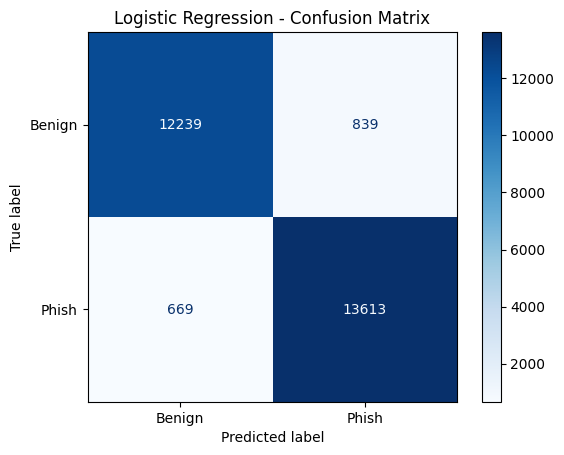

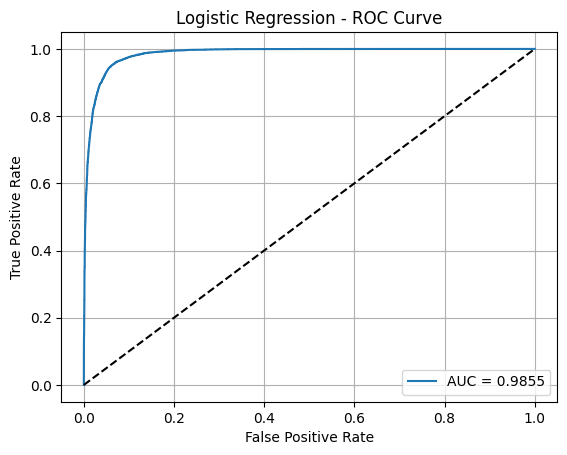


--- Fold 2 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9485    0.9350    0.9417     13078
           1     0.9412    0.9535    0.9473     14281

    accuracy                         0.9447     27359
   macro avg     0.9449    0.9443    0.9445     27359
weighted avg     0.9447    0.9447    0.9446     27359



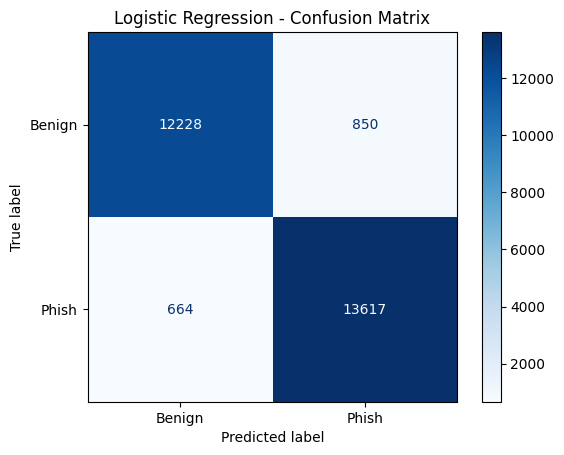

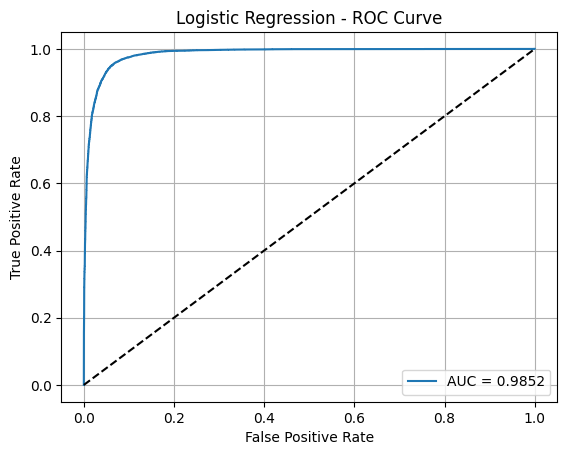


--- Fold 3 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9610    0.9431    0.9520     13077
           1     0.9488    0.9650    0.9568     14282

    accuracy                         0.9545     27359
   macro avg     0.9549    0.9540    0.9544     27359
weighted avg     0.9546    0.9545    0.9545     27359



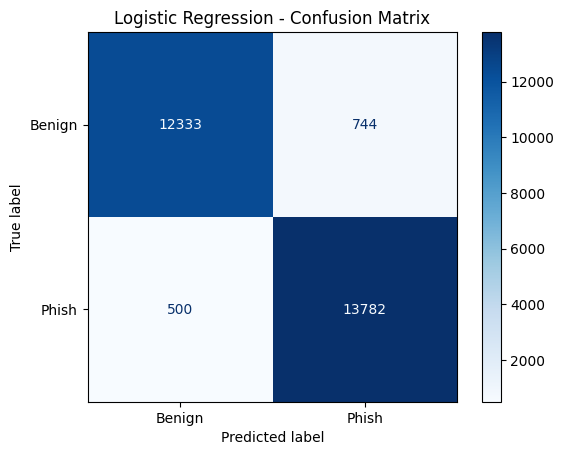

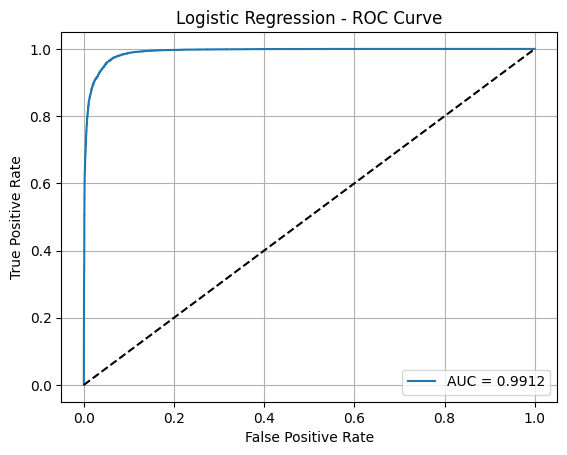


Average CV Scores:
Accuracy: 0.9480
Precision: 0.9440
Recall: 0.9572
F1-score: 0.9506
AUC: 0.9873

====== Random Forest ======


--- Fold 1 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9835    0.9734    0.9784     13078
           1     0.9759    0.9851    0.9805     14282

    accuracy                         0.9795     27360
   macro avg     0.9797    0.9792    0.9794     27360
weighted avg     0.9795    0.9795    0.9795     27360



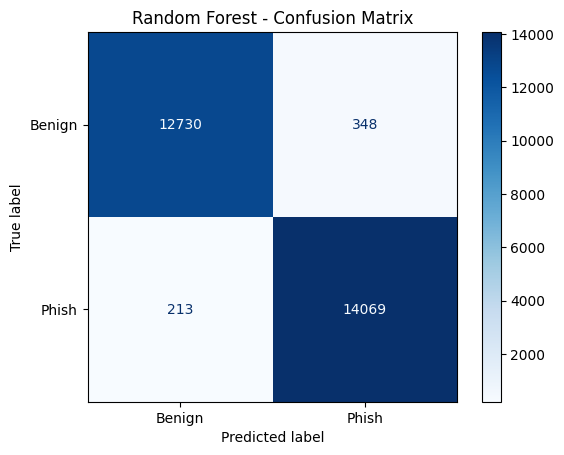

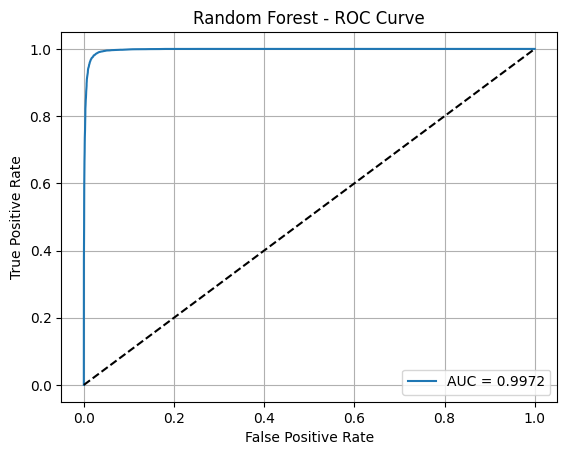


--- Fold 2 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9831    0.9764    0.9797     13078
           1     0.9785    0.9846    0.9815     14281

    accuracy                         0.9807     27359
   macro avg     0.9808    0.9805    0.9806     27359
weighted avg     0.9807    0.9807    0.9807     27359



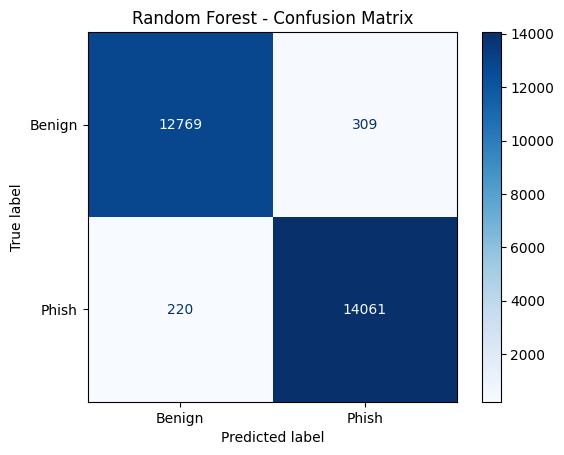

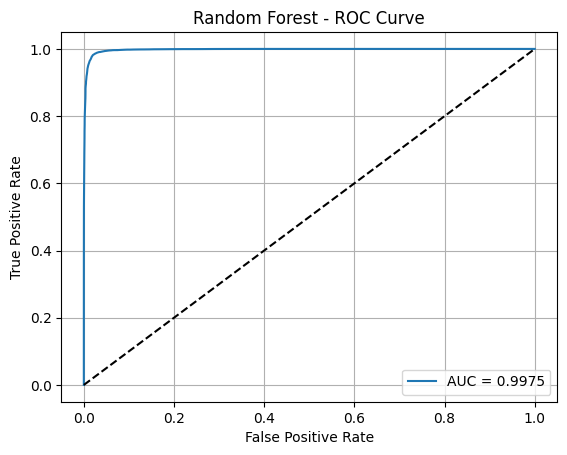


--- Fold 3 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9852    0.9729    0.9790     13077
           1     0.9754    0.9866    0.9810     14282

    accuracy                         0.9800     27359
   macro avg     0.9803    0.9797    0.9800     27359
weighted avg     0.9801    0.9800    0.9800     27359



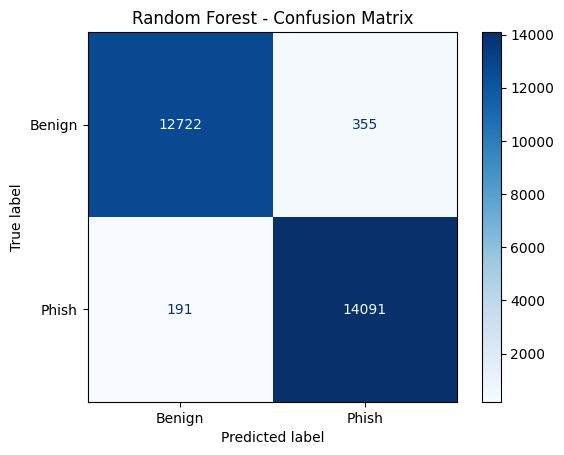

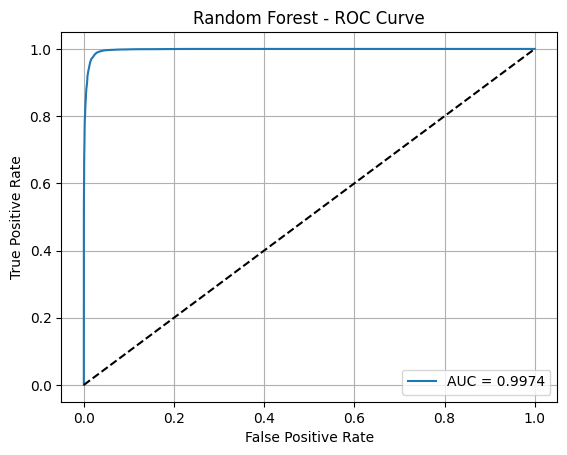


Average CV Scores:
Accuracy: 0.9801
Precision: 0.9766
Recall: 0.9854
F1-score: 0.9810
AUC: 0.9974

====== Linear SVM ======


--- Fold 1 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9706    0.9576    0.9641     13078
           1     0.9617    0.9735    0.9675     14282

    accuracy                         0.9659     27360
   macro avg     0.9662    0.9656    0.9658     27360
weighted avg     0.9660    0.9659    0.9659     27360



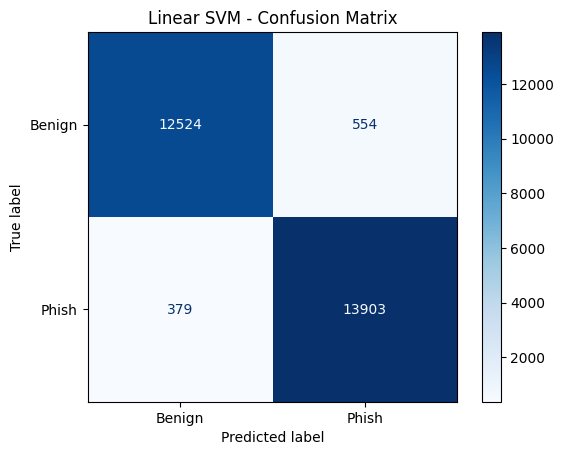


--- Fold 2 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9691    0.9583    0.9637     13078
           1     0.9622    0.9721    0.9671     14281

    accuracy                         0.9655     27359
   macro avg     0.9657    0.9652    0.9654     27359
weighted avg     0.9655    0.9655    0.9655     27359



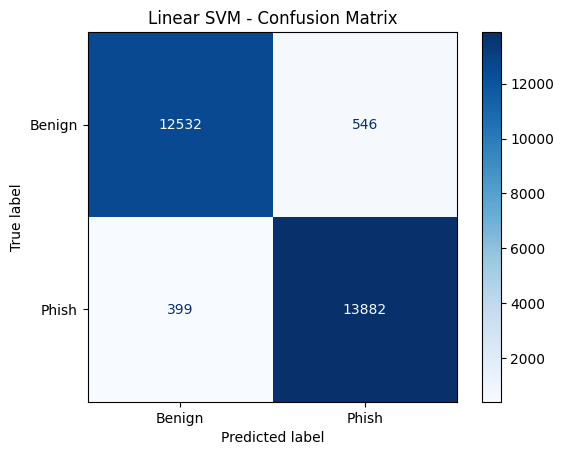


--- Fold 3 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9707    0.9582    0.9644     13077
           1     0.9621    0.9735    0.9678     14282

    accuracy                         0.9662     27359
   macro avg     0.9664    0.9659    0.9661     27359
weighted avg     0.9662    0.9662    0.9662     27359



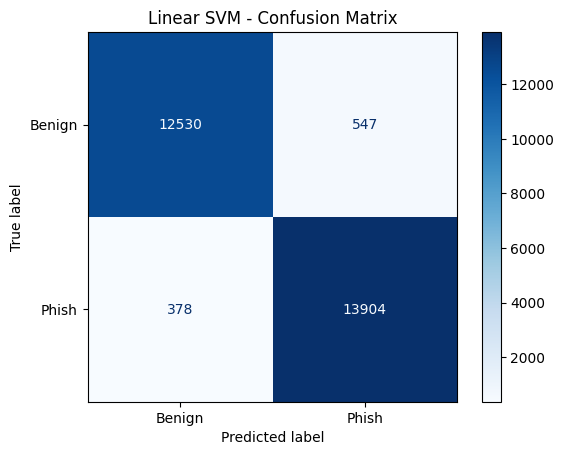


Average CV Scores:
Accuracy: 0.9658
Precision: 0.9620
Recall: 0.9730
F1-score: 0.9675

====== XGBoost ======


--- Fold 1 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9841    0.9671    0.9755     13078
           1     0.9704    0.9857    0.9780     14282

    accuracy                         0.9768     27360
   macro avg     0.9772    0.9764    0.9768     27360
weighted avg     0.9769    0.9768    0.9768     27360



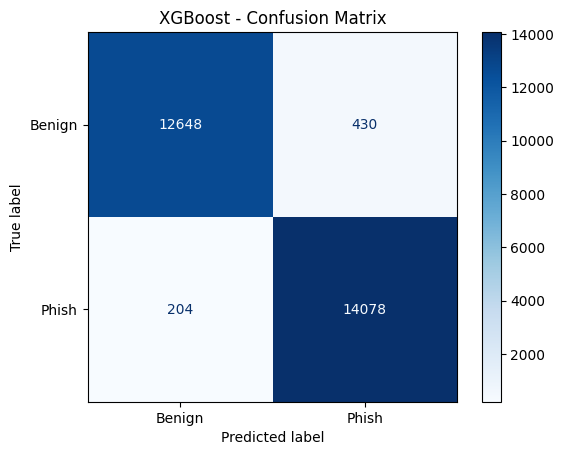

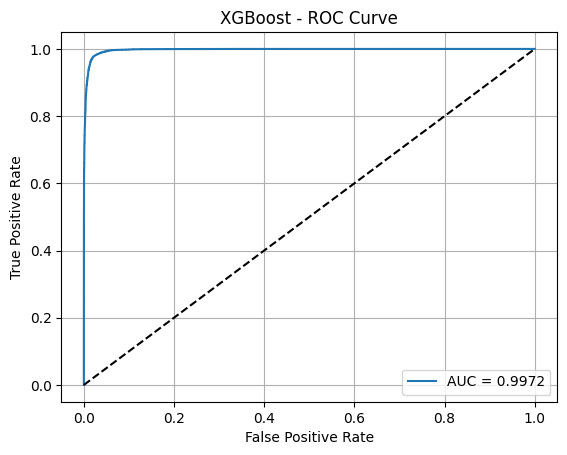


--- Fold 2 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9842    0.9706    0.9773     13078
           1     0.9734    0.9857    0.9795     14281

    accuracy                         0.9785     27359
   macro avg     0.9788    0.9781    0.9784     27359
weighted avg     0.9785    0.9785    0.9785     27359



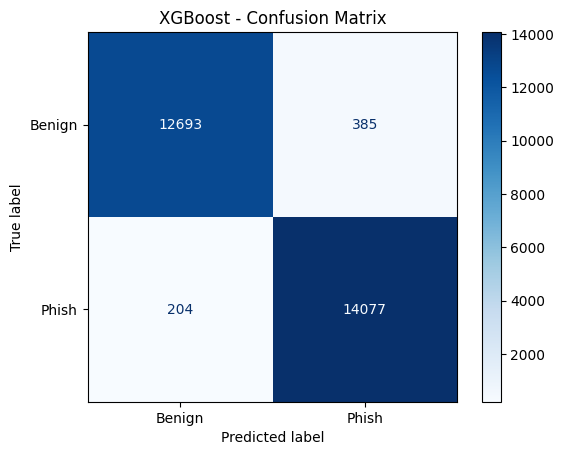

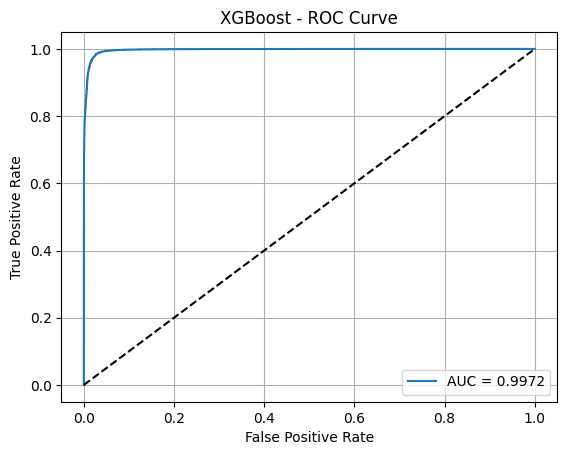


--- Fold 3 ---
Classification Report:
              precision    recall  f1-score   support

           0     0.9858    0.9667    0.9762     13077
           1     0.9701    0.9873    0.9786     14282

    accuracy                         0.9774     27359
   macro avg     0.9779    0.9770    0.9774     27359
weighted avg     0.9776    0.9774    0.9774     27359



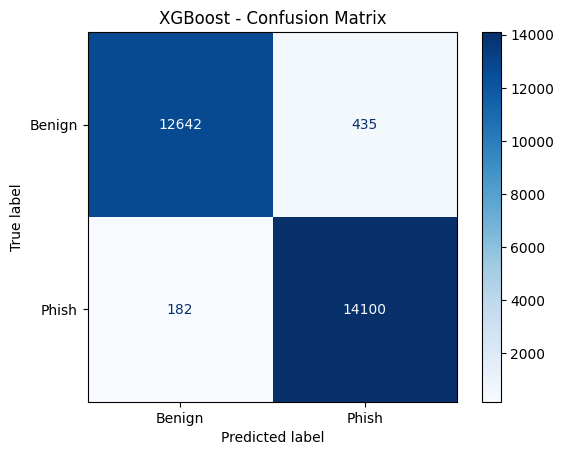

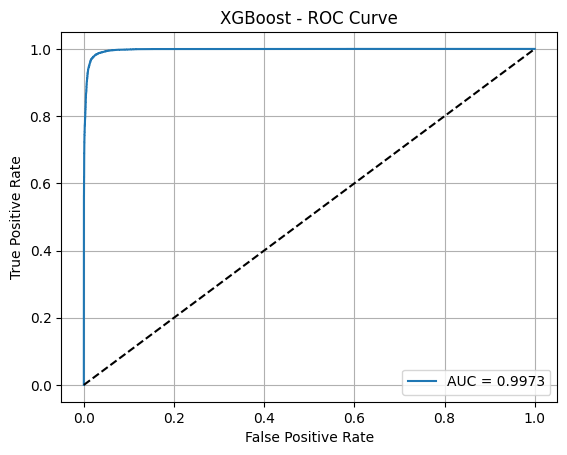


Average CV Scores:
Accuracy: 0.9776
Precision: 0.9713
Recall: 0.9862
F1-score: 0.9787
AUC: 0.9972


In [11]:
y_np = y.to_numpy()


lr_model = LogisticRegression(max_iter=500, random_state=42)
evaluate_model_cv_and_plot(lr_model, X_combined, y_np, "Logistic Regression")


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
evaluate_model_cv_and_plot(rf_model, X_combined, y_np, "Random Forest")


svm_model = LinearSVC(random_state=42)
evaluate_model_cv_and_plot(svm_model, X_tfidf, y_np, "Linear SVM", use_proba=False)


xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(len(y) - sum(y)) / sum(y)
)
evaluate_model_cv_and_plot(xgb_model, X_combined, y_np, "XGBoost")